# Benchmark: Screen Tracking Optimizations in Isolation
This notebook benchmarks the effect of the optimizations made in `cheetah/accelerator/screen.py` in isolation.
Specifically, we compare:
1. **Original Screen logic**: Accesses `self.pixel_bin_centers` and `self.pixel_bin_edges` multiple times (causing 8 `torch.linspace` evaluations per track) and copies the extent bounds from CPU to GPU (`read_beam.particles.new_tensor`).
2. **Optimized Screen logic**: Caches `self.pixel_bin_edges` (reducing linspace overhead to 2 calls) and allocates the `extent` tensor directly on the target device.

Both versions use the **current optimized Cloud-in-Cell** implementation, isolating the performance gains solely to the changes in the `Screen` tracking class.

In [1]:
import sys
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import platform
import subprocess
import re
import glob

repo_root = os.path.abspath(".")
if repo_root not in sys.path:
    sys.path.append(repo_root)

import cheetah
import cheetah.utils.cloud_in_cell as cic_tensor

device_types = ["cpu"]
if torch.cuda.is_available():
    device_types.append("cuda")
if torch.backends.mps.is_available():
    device_types.append("mps")
print(f"Available devices: {device_types}")

def sync(device):
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()

Available devices: ['cpu', 'mps']


In [2]:
def get_cpu_info():
    try:
        if platform.system() == "Windows":
            return platform.processor()
        elif platform.system() == "Darwin":
            return subprocess.check_output(["sysctl", "-n", "machdep.cpu.brand_string"]).decode().strip()
        elif platform.system() == "Linux":
            with open("/proc/cpuinfo", "r") as f:
                for line in f:
                    if "model name" in line:
                        return re.sub(".*model name.*:", "", line, 1).strip()
    except Exception:
        pass
    return platform.processor() or "Unknown CPU"

def get_ram_info():
    try:
        import psutil
        return f"{psutil.virtual_memory().total / (1024**3):.1f} GB"
    except ImportError:
        pass
    try:
        if platform.system() == "Darwin":
            mem_bytes = int(subprocess.check_output(["sysctl", "-n", "hw.memsize"]).decode().strip())
            return f"{mem_bytes / (1024**3):.1f} GB"
        elif platform.system() == "Linux":
            with open("/proc/meminfo", "r") as f:
                for line in f:
                    if "MemTotal" in line:
                        mem_kb = int(line.split()[1])
                        return f"{mem_kb / (1024**2):.1f} GB"
    except Exception:
        pass
    return "Unknown RAM"

def get_gpu_info():
    gpus = []
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            gpus.append(torch.cuda.get_device_name(i))
    if torch.backends.mps.is_available():
        gpus.append("Apple Silicon Integrated GPU (MPS)")
    return ", ".join(gpus) if gpus else "None"

cpu_info = get_cpu_info()
ram_info = get_ram_info()
gpu_info = get_gpu_info()
os_info = f"{platform.system()} {platform.release()}"

system_label = f"{os_info} | {cpu_info} | RAM: {ram_info}"
if gpu_info != "None":
    system_label += f" | GPU: {gpu_info}"

print("System Information:")
print(f"OS:  {os_info}")
print(f"CPU: {cpu_info}")
print(f"RAM: {ram_info}")
print(f"GPU: {gpu_info}")
print(f"Label: {system_label}")

System Information:
OS:  Darwin 25.5.0
CPU: Apple M1 Pro
RAM: 32.0 GB
GPU: Apple Silicon Integrated GPU (MPS)
Label: Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | GPU: Apple Silicon Integrated GPU (MPS)


In [3]:
def reading_original(screen: cheetah.Screen) -> torch.Tensor:
    read_beam = screen.get_read_beam()
    if read_beam is None:
        return screen.misalignment.new_zeros(
            (int(screen.effective_resolution[1]), int(screen.effective_resolution[0]))
        )
    
    weights = read_beam.particle_charges.abs() * read_beam.survival_probabilities
    broadcasted_x, broadcasted_y, broadcasted_weights = (
        torch.broadcast_tensors(read_beam.x, read_beam.y, weights)
    )
    
    # Original way:
    image = cic_tensor.cloud_in_cell_charge_deposition(
        positions=torch.stack([broadcasted_x, broadcasted_y], dim=-1),
        bins=[
            len(screen.pixel_bin_centers[0]),
            len(screen.pixel_bin_centers[1]),
        ],
        extent=read_beam.particles.new_tensor(
            [
                [screen.pixel_bin_edges[0][0], screen.pixel_bin_edges[0][-1]],
                [screen.pixel_bin_edges[1][0], screen.pixel_bin_edges[1][-1]],
            ]
        ),
        charges=broadcasted_weights,
    ).mT
    return image

def reading_optimized(screen: cheetah.Screen) -> torch.Tensor:
    read_beam = screen.get_read_beam()
    if read_beam is None:
        return screen.misalignment.new_zeros(
            (int(screen.effective_resolution[1]), int(screen.effective_resolution[0]))
        )
    
    weights = read_beam.particle_charges.abs() * read_beam.survival_probabilities
    broadcasted_x, broadcasted_y, broadcasted_weights = (
        torch.broadcast_tensors(read_beam.x, read_beam.y, weights)
    )
    
    # Optimized (current) way:
    edges_x, edges_y = screen.pixel_bin_edges
    extent = torch.tensor(
        [[edges_x[0], edges_x[-1]], [edges_y[0], edges_y[-1]]],
        device=read_beam.particles.device,
        dtype=read_beam.particles.dtype,
    )
    image = cic_tensor.cloud_in_cell_charge_deposition(
        positions=torch.stack([broadcasted_x, broadcasted_y], dim=-1),
        bins=[len(edges_x) - 1, len(edges_y) - 1],
        extent=extent,
        charges=broadcasted_weights,
    ).mT
    return image

In [4]:
# Quick sanity check for equivalence
device = torch.device("cpu")
particles = torch.zeros(2, 10, 100, 7, device=device)
particles[..., 0] = torch.randn(2, 10, 100, device=device) * 1e-4
particles[..., 2] = torch.randn(2, 10, 100, device=device) * 1e-4
beam = cheetah.ParticleBeam(particles=particles, energy=torch.tensor(1e9, device=device), device=device)

screen = cheetah.Screen(
    resolution=(150, 150),
    pixel_size=torch.tensor((1e-6, 1e-6), device=device),
    is_active=True,
    method="cloud-in-cell",
    device=device
)
screen.track(beam)

img_orig = reading_original(screen)
img_opt = reading_optimized(screen)
diff = torch.max(torch.abs(img_orig - img_opt))
print(f"Max Difference: {diff.item():.2e}")

Max Difference: 0.00e+00


In [5]:
def run_benchmark(num_runs=20):
    results = []
    H, W = 150, 150
    num_particles = 100000
    batch_shapes = [(20, 1), (2, 10)]
    
    for device_name in device_types:
        device = torch.device(device_name)
        for batch_shape in batch_shapes:
            particles = torch.zeros(*batch_shape, num_particles, 7, device=device)
            particles[..., 0] = torch.randn(*batch_shape, num_particles, device=device) * 1e-4
            particles[..., 2] = torch.randn(*batch_shape, num_particles, device=device) * 1e-4
            beam = cheetah.ParticleBeam(particles=particles, energy=torch.tensor(1.0e9, device=device), device=device)
            
            screen = cheetah.Screen(
                resolution=(W, H),
                pixel_size=torch.tensor((1e-6, 1e-6), device=device),
                is_active=True,
                method="cloud-in-cell",
                device=device
            )
            screen.track(beam)
            
            # Warmups
            for _ in range(3):
                _ = reading_original(screen)
                _ = reading_optimized(screen)
            sync(device)
            
            # Benchmark Original
            t_orig = []
            for _ in range(num_runs):
                t0 = time.perf_counter()
                _ = reading_original(screen)
                sync(device)
                t_orig.append(time.perf_counter() - t0)
                
            # Benchmark Optimized
            t_opt = []
            for _ in range(num_runs):
                t0 = time.perf_counter()
                _ = reading_optimized(screen)
                sync(device)
                t_opt.append(time.perf_counter() - t0)
                
            results.append({
                "Device": device_name.upper(),
                "Batch Shape": str(batch_shape),
                "Original Screen (s)": np.mean(t_orig),
                "Optimized Screen (s)": np.mean(t_opt),
                "Speedup": np.mean(t_orig) / np.mean(t_opt)
            })
            
    df = pd.DataFrame(results)
    return df

df_res = run_benchmark()
df_res

,Device,Batch Shape,Original Screen (s),Optimized Screen (s),Speedup
0,CPU,"(20, 1)",0.043720,0.043729,0.999789
1,CPU,"(2, 10)",0.046094,0.045766,1.007177
2,MPS,"(20, 1)",0.031790,0.020130,1.579189
3,MPS,"(2, 10)",0.033045,0.020522,1.610207


In [6]:
# Save results
run_data = []
for idx, row in df_res.iterrows():
    run_data.append({
        "System": system_label,
        "Device": row["Device"],
        "Batch Shape": row["Batch Shape"],
        "Original Screen (s)": row["Original Screen (s)"],
        "Optimized Screen (s)": row["Optimized Screen (s)"],
        "Speedup": row["Speedup"]
    })
df_run = pd.DataFrame(run_data)

system_slug = re.sub(r'[^a-z0-9]+', '_', system_label.lower()).strip('_')
results_dir = os.path.join(repo_root, "dev", "benchmark_results")
os.makedirs(results_dir, exist_ok=True)
csv_filename = os.path.join(results_dir, f"screen_opt_results_{system_slug}.csv")
df_run.to_csv(csv_filename, index=False)
print(f"Saved current run results to {csv_filename}")

# Load all screen isolation results
all_files = glob.glob(os.path.join(results_dir, "screen_opt_results_*.csv"))
print(f"Found {len(all_files)} screen isolation benchmark results files:")
all_dfs = []
for file in all_files:
    print(f" - {os.path.basename(file)}")
    all_dfs.append(pd.read_csv(file))
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df

Saved current run results to /Users/jankaiser/Documents/DESY/cheetah/dev/benchmark_results/screen_opt_results_darwin_25_5_0_apple_m1_pro_ram_32_0_gb_gpu_apple_silicon_integrated_gpu_mps.csv
Found 2 screen isolation benchmark results files:
 - screen_opt_results_darwin_25_5_0_apple_m1_pro_ram_32_0_gb_gpu_apple_silicon_integrated_gpu_mps.csv
 - screen_opt_results_linux_5_14_0_687_13_1_el9_8_x86_64_amd_epyc_7513_32_core_processor_ram_503_2_gb_gpu_nvidia_a100_80gb_pcie.csv


,System,Device,Batch Shape,Original Screen (s),Optimized Screen (s),Speedup
0,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,CPU,"(20, 1)",0.043720,0.043729,0.999789
1,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,CPU,"(2, 10)",0.046094,0.045766,1.007177
2,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,MPS,"(20, 1)",0.031790,0.020130,1.579189
3,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,MPS,"(2, 10)",0.033045,0.020522,1.610207
4,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,"(20, 1)",0.024583,0.022154,1.109631
5,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,"(2, 10)",0.018023,0.016432,1.096782
6,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CUDA,"(20, 1)",0.003774,0.001887,2.000012
7,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CUDA,"(2, 10)",0.003772,0.001881,2.005582


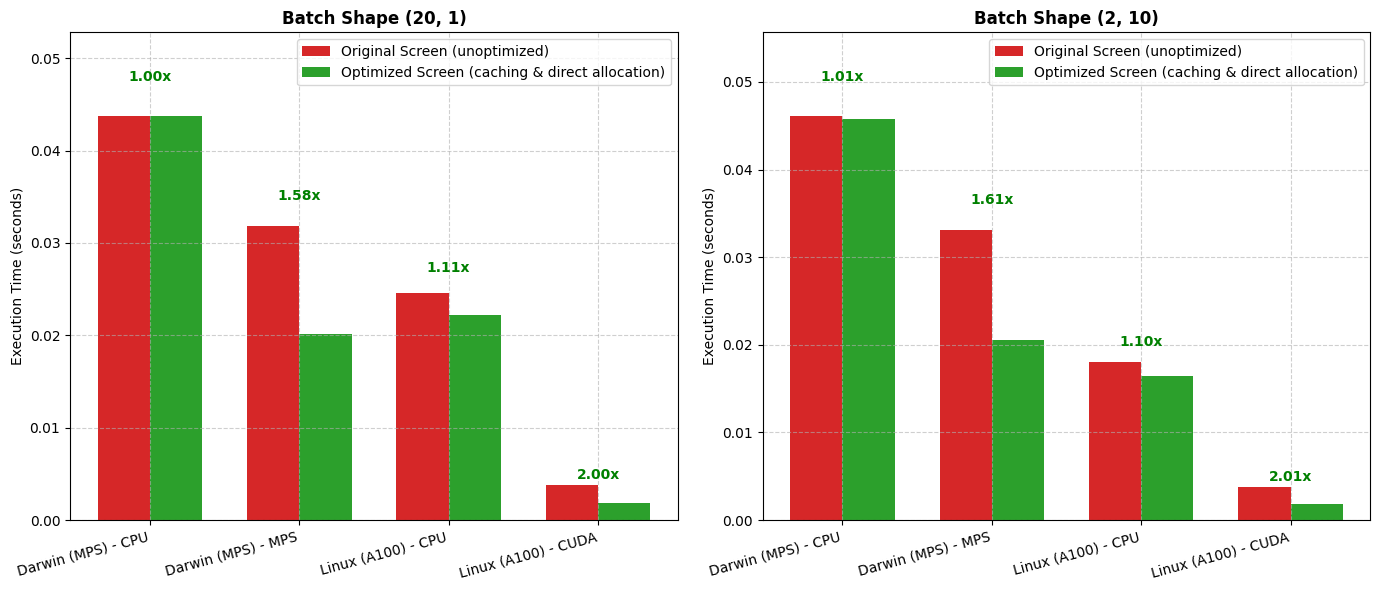

In [7]:
def plot_screen_isolation(df):
    # Get unique system + device configurations
    configs = []
    for idx, row in df.iterrows():
        sys_name = row["System"]
        device = row["Device"]
        os_name = sys_name.split("|")[0].strip().split()[0]
        
        gpu_part = ""
        if "GPU:" in sys_name:
            gpu_name = sys_name.split("GPU:")[-1].strip()
            if "A100" in gpu_name:
                gpu_part = " (A100)"
            elif "MPS" in gpu_name:
                gpu_part = " (MPS)"
        
        label = f"{os_name}{gpu_part} - {device}"
        configs.append((sys_name, device, label))
        
    configs = list(set(configs))
    configs.sort(key=lambda x: x[2])
    
    batch_shapes = ["(20, 1)", "(2, 10)"]
    fig, axes = plt.subplots(1, len(batch_shapes), figsize=(14, 6), squeeze=False)
    
    for col_idx, shape in enumerate(batch_shapes):
        ax = axes[0, col_idx]
        sub_df = df[df["Batch Shape"] == shape]
        
        x_labels = []
        orig_times = []
        opt_times = []
        speedups = []
        
        for _, (sys_name, dev, label) in enumerate(configs):
            config_df = sub_df[(sub_df["System"] == sys_name) & (sub_df["Device"] == dev)]
            if not config_df.empty:
                x_labels.append(label)
                orig_times.append(config_df["Original Screen (s)"].iloc[0])
                opt_times.append(config_df["Optimized Screen (s)"].iloc[0])
                speedups.append(config_df["Speedup"].iloc[0])
                
        x = np.arange(len(x_labels))
        width = 0.35
        
        rects1 = ax.bar(x - width/2, orig_times, width, label="Original Screen (unoptimized)", color="#d62728")
        rects2 = ax.bar(x + width/2, opt_times, width, label="Optimized Screen (caching & direct allocation)", color="#2ca02c")
        
        ax.set_title(f"Batch Shape {shape}", fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=15, ha="right")
        ax.set_ylabel("Execution Time (seconds)")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.6)
        
        # Add speedup label on top of bars (with linear y-axis)
        for i in range(len(x_labels)):
            val = speedups[i]
            max_val = max(orig_times[i], opt_times[i])
            ax.text(i, max_val * 1.08,
                    f"{val:.2f}x", ha="center", va="bottom", color="green", fontweight="bold")
            
        # Adjust y-limits to make room for labels
        _, y_max = ax.get_ylim()
        ax.set_ylim(top=y_max * 1.15)
        
    plt.tight_layout()
    plt.savefig("screen_optimization_comparison.png", dpi=300)
    plt.show()

plot_screen_isolation(combined_df)